# Validation, reproducibility, and interview defense

[Run in browser](https://muzammilafroz.github.io/isb-spia-data-test-learning-lab/lab/index.html?path=lessons/05_validation_reproducibility_defense.ipynb) | [Open in Colab](https://colab.research.google.com/github/muzammilafroz/isb-spia-data-test-learning-lab/blob/main/notebooks/lessons/05_validation_reproducibility_defense.ipynb) | [Course home](https://muzammilafroz.github.io/isb-spia-data-test-learning-lab/) | [Take the test](https://muzammilafroz.github.io/isb-spia-data-test-learning-lab/tests/?module=module-05)

> This independent learning resource uses fictional, synthetic data. It is not an official ISB or SPIA product or credential.

## Why this lesson matters

Good analysis is a chain of claims that another person can check. Reproducibility, artifact inspection, troubleshooting, and honest disclosure are part of the analysis, not chores added at the end.

Prerequisites: Lessons 1 through 4.

In [1]:
from __future__ import annotations

import os
import sys
import types
from urllib.request import urlopen

if sys.platform == "emscripten":
    import piplite
    await piplite.install("pyodide-http")
    import pyodide_http
    pyodide_http.patch_all()

RAW_CODE_ROOT = "https://raw.githubusercontent.com/muzammilafroz/isb-spia-data-test-learning-lab/v1.0.0/learning_lab"
if sys.platform == "emscripten":
    from js import window
    if window.location.hostname in {"127.0.0.1", "localhost"}:
        RAW_CODE_ROOT = f"{window.location.origin}/learning_lab"
        os.environ["LEARNING_LAB_DATA_BASE"] = f"{window.location.origin}/data/teaching"

def load_public_module(module_name):
    """Import locally, or fetch the small public helper when running in Colab/Lite."""
    try:
        return __import__(f"learning_lab.{module_name}", fromlist=[module_name])
    except ModuleNotFoundError:
        location = f"{RAW_CODE_ROOT}/{module_name}.py"
        source = urlopen(location).read().decode("utf-8")
        module = types.ModuleType(f"learning_lab.{module_name}")
        exec(compile(source, location, "exec"), module.__dict__)
        return module

lab_io = load_public_module("io")
get_data_url = lab_io.get_data_url
read_teaching_csv = lab_io.read_teaching_csv
read_teaching_geojson = lab_io.read_teaching_geojson

print("Runtime:", sys.platform)
print("Data reference:", os.getenv("LEARNING_LAB_DATA_REF", "v1.0.0"))

Runtime: win32
Data reference: v1.0.0


In [2]:
import hashlib
import json
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

manifest_location = get_data_url("data_manifest.json")
expected_location = get_data_url("expected_outputs.json")

def read_json(location):
    if str(location).startswith(("http://", "https://")):
        return json.loads(urlopen(location).read().decode("utf-8"))
    return json.loads(Path(location).read_text(encoding="utf-8"))

manifest = read_json(manifest_location)
expected = read_json(expected_location)
print("Synthetic only:", manifest["synthetic_only"])
print("Generated files recorded:", len(manifest["files"]))

Synthetic only: True
Generated files recorded: 11


## Fresh-kernel execution

Interactive notebooks remember variables from earlier cells. A cell may appear to work only because an old variable still exists. Restarting the kernel, clearing state, and running top to bottom tests whether the notebook contains every import and step it needs in the correct order.

A successful fresh run proves executability in that environment. It does not by itself prove that the analysis choices are valid.

In [3]:
required_expected_keys = {
    "district_count", "sampling_point_count", "test_slot_count",
    "valid_rate_households", "clean_analysis_rows",
}
assert required_expected_keys.issubset(expected)
assert manifest["generator_seed"] == 20260827
assert manifest["synthetic_only"] is True
print("Manifest and expected-output schema checks passed.")

Manifest and expected-output schema checks passed.


## Hashes detect input drift

SHA-256 maps file bytes to a fixed-length fingerprint. If one byte changes, the fingerprint is overwhelmingly likely to change. A hash does not tell you whether a dataset is substantively correct, but it detects unexpected byte changes.

In [4]:
production_location = get_data_url("district_production.csv")
if str(production_location).startswith(("http://", "https://")):
    production_bytes = urlopen(production_location).read()
else:
    production_bytes = Path(production_location).read_bytes()

observed_hash = hashlib.sha256(production_bytes).hexdigest()
recorded_hash = next(
    item["sha256"] for item in manifest["files"]
    if item["file"] == "district_production.csv"
)
assert observed_hash == recorded_hash
print("Production file hash matches the manifest.")

Production file hash matches the manifest.


## Inspect the exact saved artifact

The code below saves a small figure into a temporary directory, opens that exact PNG with Pillow, verifies its dimensions, and leaves no file behind after the context closes. Human visual review must still check clipping, overlap, contrast, and meaning.

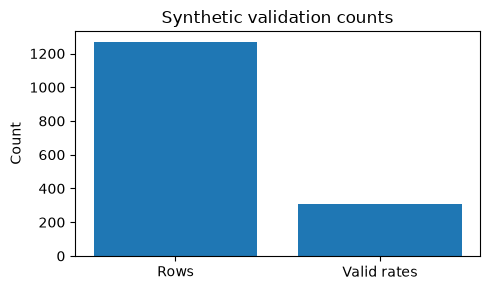

Saved format: PNG
Saved pixel size: (700, 420)


In [5]:
with tempfile.TemporaryDirectory(prefix="learning-lab-figure-") as folder:
    figure_path = Path(folder) / "validation_example.png"
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(["Rows", "Valid rates"], [expected["clean_analysis_rows"], expected["valid_rate_households"]])
    ax.set(title="Synthetic validation counts", ylabel="Count")
    fig.tight_layout()
    fig.savefig(figure_path, dpi=140)
    plt.show()
    plt.close(fig)

    with Image.open(figure_path) as saved:
        print("Saved format:", saved.format)
        print("Saved pixel size:", saved.size)
        assert saved.format == "PNG"
        assert saved.width >= 600 and saved.height >= 350

## A validation loop

1. State the claim and expected unit.
2. Produce the number or artifact with code.
3. Check keys, ranges, row counts, hashes, and model samples.
4. Open rendered outputs and inspect them.
5. Record failures and corrections.
6. Re-run the affected check from clean state.

What would break if we skipped step 5? The final artifact might look correct, but a reviewer could not reconstruct how a defect was found and repaired.

## Troubleshooting by symptom

| Symptom | Likely cause | First check |
|---|---|---|
| `ModuleNotFoundError` | Environment not synchronized | Confirm the intended kernel and dependencies |
| HTTP error | Wrong data ref or unpublished tag | Print `get_data_url()` and check the release |
| Merge error | Duplicate or malformed key | Inspect uniqueness and normalized IDs on both sides |
| Singular design | Redundant indicator columns | Compare matrix rank with column count |
| Different result after restart | Hidden notebook state | Run every cell top to bottom in a fresh kernel |
| Clipped legend | No reserved layout space | Open the exact image and adjust margins |

## Honest AI disclosure

A defensible disclosure is specific: describe which tasks used AI assistance, identify the data and code checks you performed yourself, and accept responsibility for the final work. Do not deny assistance, transfer responsibility to a tool, or imply that generated text proves empirical accuracy.

Example: `AI assistance helped organize explanations and review code structure. I executed the notebooks, checked every reported value against generated artifacts, inspected the saved figures, and remain responsible for the analysis and its limitations.`

## Interview defense pattern

Use five parts: purpose, data constraint, decision, validation, limitation. For example: `I joined on the unique district code because the display name was duplicated. I asserted uniqueness on both sides, used one-to-one merge validation, and checked that every geometry matched. A name join would be acceptable only after a separately audited crosswalk made names unique.`

Finish the module test, then take the capstone. The browser stores progress locally and can issue an unofficial local completion record after all six assessments are passed.